# Chromatin Peak to Trough Analysis and Metrics

Summarize the chromatin peak-to-trough ratios for each gene. There will be a few methods we can try. 

1. First, let's get an idea of what the peak-to-trough ratio values are for all the chromatin cells for all genes.
2. Then, try a few threshold values to get a sense of how we can partition the genes into cell cycling and non-cell cycling gene groups


In [51]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

In [99]:
analysis = PeakToTroughAnalysis()

Created a dictionary of PTR arrays of size: 5402
So, there were 372 genes that did not deconvolve
Created a numpy array of all deconvolved gene PTRs of shape: (5774, 3, 9)
5344 genes have non-nan deconvolution chromatin PTRs


Truncating large PTR outlier values (1 gene). So N=5755


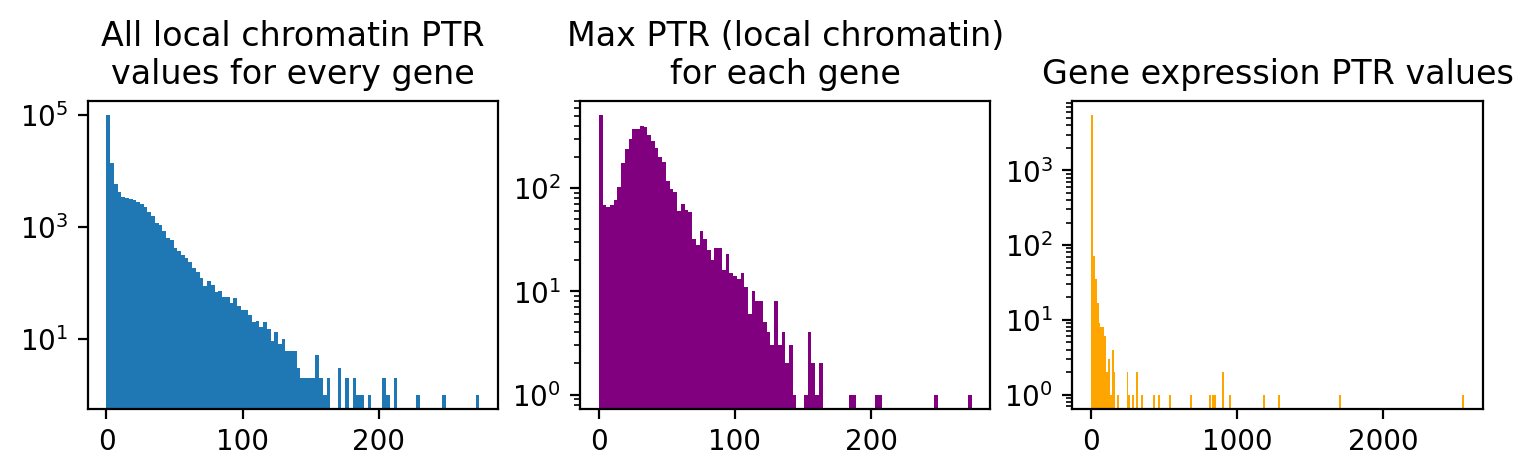

In [101]:
analysis.plot_histograms()

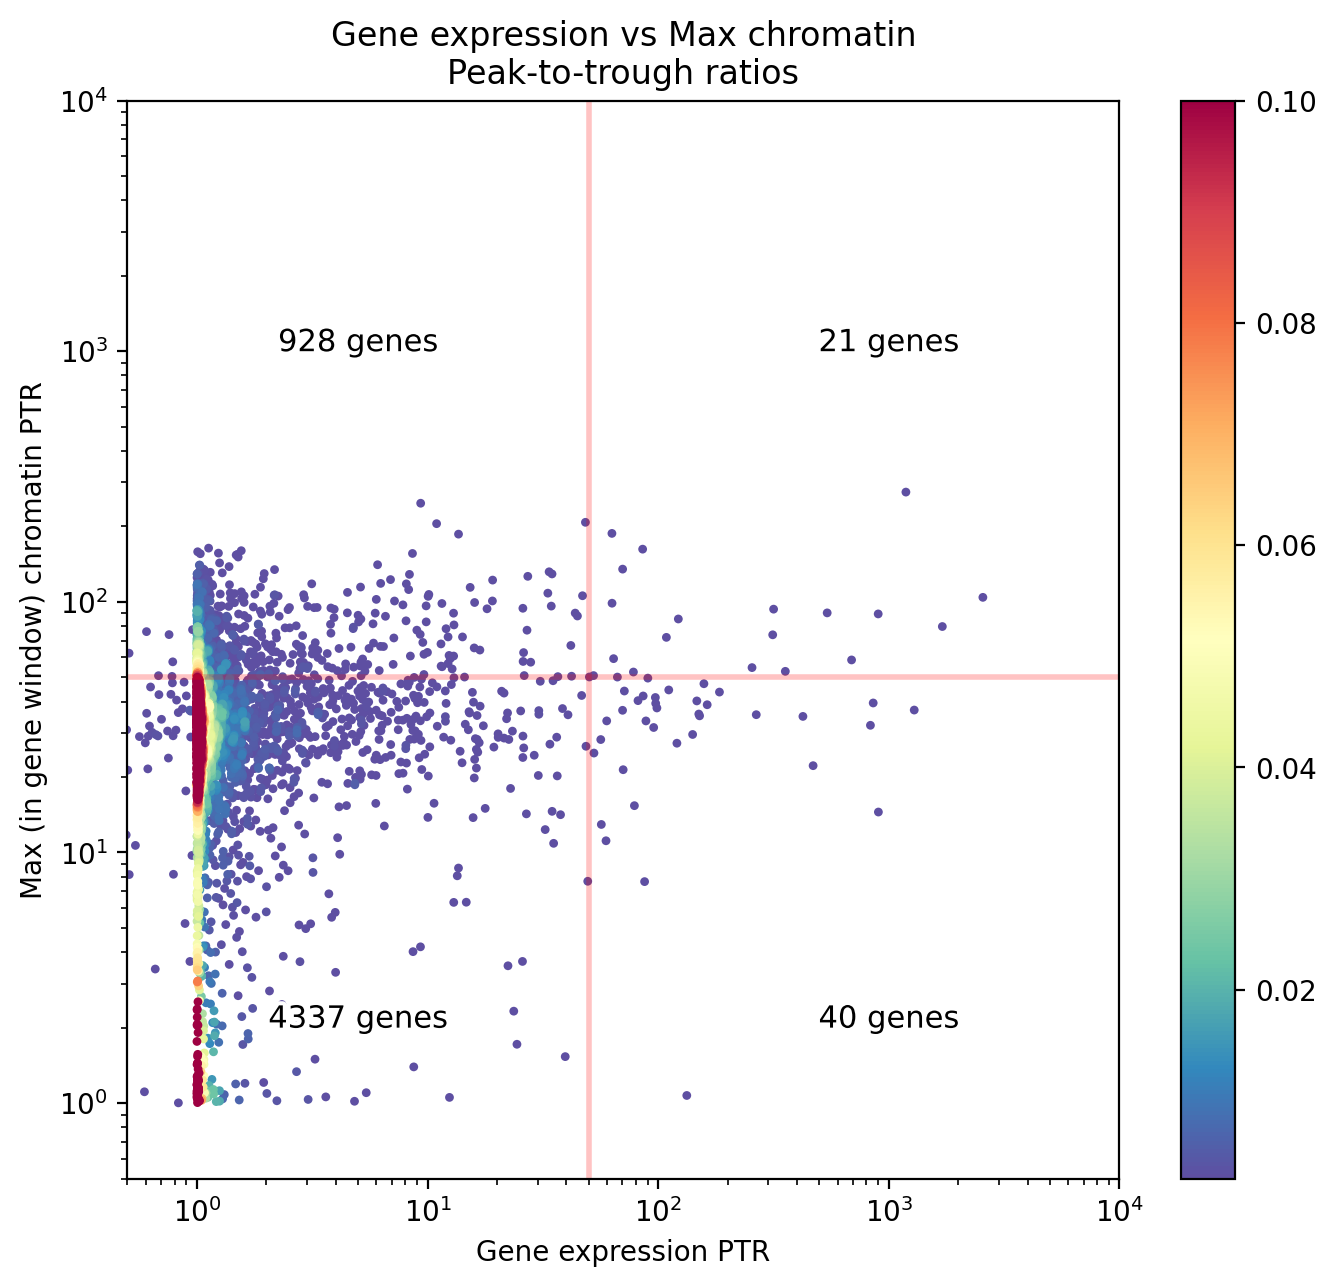

In [181]:
from cc_src.DensityScatterPlotter import DensityScatterPlotter

plt.figure(figsize=(8, 7))
plt_data = analysis.combined_ptr_dfs.copy()
plt_data = plt_data.dropna()

density_plotter = DensityScatterPlotter()
density_plotter.bw = [0.01, 1]
density_plotter.cmap = 'Spectral_r'

ax = plt.gca()

x, y = plt_data.ge_ptr, plt_data.max_chrom_ptr

density_plotter.set_data(x, y)
ax = density_plotter.plot_ax(plt.gca(), plot_colorbar=True, vmax=0.1)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Gene expression PTR")
ax.set_ylabel("Max (in gene window) chromatin PTR")

xlim = 0.5, 1e4
ylim = 0.5, 1e4
cutoff = 50, 50

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_title("Gene expression vs Max chromatin\nPeak-to-trough ratios")

ax.axvline(cutoff[0], c='red', alpha=0.236, lw=2)
ax.axhline(cutoff[1], c='red', alpha=0.236, lw=2)


def _plot_num_genes(ax, x, y, num_quad):
    import matplotlib.patheffects as path_effects
    text = ax.text(x, y, f"{num_quad} genes", zorder=100, color='black', fontsize=11,
                   ha='center')
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
                           path_effects.Normal()])

num_quad = len(plt_data[(x > cutoff[0]) & (y > cutoff[0])])
_plot_num_genes(ax, 1000, 1000, num_quad)

num_quad = len(plt_data[(x < cutoff[0]) & (y < cutoff[0])])
_plot_num_genes(ax, 5, 2, num_quad)

num_quad = len(plt_data[(x > cutoff[0]) & (y < cutoff[0])])
_plot_num_genes(ax, 1000, 2, num_quad)

num_quad = len(plt_data[(x < cutoff[0]) & (y > cutoff[0])])
_plot_num_genes(ax, 5, 1000, num_quad)
